# Aprendizaje No Supervisado — Segmentación de Muestras de Agua

**Dominio:** Medio Ambiente / Calidad del agua

**Dataset:** Water Quality Dataset

**Problema:** Clustering / segmentación no supervisada — descubrir perfiles naturales de muestras de agua a partir de sus características fisicoquímicas,
**sin usar la etiqueta `Potability`**.

**Modelos:** K-means, DBSCAN

**Reducción de dimensionalidad:** PCA (lineal), t-SNE (no lineal)

**Grupo 8**

---

### Justificación del enfoque

A diferencia del enfoque supervisado, aquí **no buscamos predecir potabilidad**: buscamos descubrir si las muestras se agrupan de forma natural en perfiles fisicoquímicos distintos. Esto es útil porque:

- Permite identificar **tipos de agua** (por ejemplo, agua muy mineralizada vs. agua blanda) sin etiquetas previas.
- Sirve para detectar **muestras anómalas** que no encajan en ningún grupo (posibles fallos de sensor o contaminación inusual).
- Es la herramienta apropiada cuando las etiquetas son escasas, caras o poco confiables.

**Variables (todas numéricas continuas, sensores):**
`ph`, `Hardness`, `Solids`, `Chloramines`, `Sulfate`, `Conductivity`, `Organic_carbon`, `Trihalomethanes`, `Turbidity`.

La variable `Potability` se **excluye del clustering** (es supervisión) y solo se usa al final como referencia externa para validar si los clusters tienen relación con la potabilidad.


---
## 0. Instalación e Importaciones

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet
print('Librerias listas.')

Librerias listas.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
RANDOM_STATE = 42

print('Todas las librerias importadas correctamente.')

Todas las librerias importadas correctamente.


---
## 1. Carga del Dataset

In [ ]:
# Carga del dataset
# --- OPCION A: Repositorio publico (descarga automatica) ---
# URL_DATASET = (
#     'https://raw.githubusercontent.com/psebrojas1722/TAREA_2/main/water_potability.csv'
# )

# --- OPCION B: Subir el archivo manualmente en Google Colab ---
# Descomentar las siguientes lineas si el repositorio es privado:
# from google.colab import files
# uploaded = files.upload()   # seleccionar dataset.csv desde tu computadora
URL_DATASET = 'dataset.csv'

try:
    df = pd.read_csv(URL_DATASET)
    print('Dataset cargado correctamente.')
    print(f'Fuente: {URL_DATASET}')
except Exception as e:
    print(f'No se pudo cargar desde URL: {e}')
    print('Usando archivo local dataset.csv ...')
    df = pd.read_csv('dataset.csv')
    print('Dataset cargado desde archivo local.')

print(f'\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dataset cargado correctamente.
Fuente: dataset.csv

Dimensiones: 3276 filas x 10 columnas


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,6.591441,146.287626,35954.204575,6.139982,324.601907,547.459500,2.849398,53.462453,2.444648,0
1,9.013239,178.916565,15699.689929,7.584121,NaN,360.676595,15.552892,63.565525,4.555436,1
2,8.812421,190.047600,24127.467460,7.636022,364.697504,504.473754,11.016626,55.410467,3.533264,1
3,9.022568,230.955513,27309.144620,6.308965,338.792934,395.165454,13.949951,58.294283,3.876861,0
4,6.537663,176.298063,35271.811778,8.358296,269.421295,415.089293,11.601953,46.025201,3.678896,0


---
## 2. Análisis Exploratorio de Datos (EDA)

> **Criterio evaluado:** Estadísticos descriptivos, visualización de correlaciones y distribuciones, eliminación/transformación de variables irrelevantes.

In [ ]:
# --- 2.1 Estadisticos descriptivos ---
print('=== Estadisticos Descriptivos ===')
display(df.describe().round(3))

print('\n=== Tipos de datos ===')
print(df.dtypes)

print('\n=== Valores nulos por variable ===')
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct_nulos})
print(resumen_nulos[resumen_nulos['Nulos'] > 0])

=== Estadisticos Descriptivos ===


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2804.000,3276.000,3276.000,3276.000,2517.000,3276.000,3276.000,3102.000,3276.000,3276.000
mean,7.047,195.821,22183.441,7.152,332.694,426.318,14.246,65.911,3.956,0.396
std,1.636,32.251,8882.503,1.579,40.004,81.141,3.327,16.838,0.758,0.489
min,0.970,67.353,-9859.436,1.849,195.735,179.299,2.586,-5.943,1.465,0.000
25%,5.924,174.572,16213.631,6.064,304.748,368.648,12.017,54.217,3.431,0.000
50%,7.032,195.811,22213.265,7.142,332.927,426.627,14.239,65.664,3.968,0.000
75%,8.171,217.403,28137.621,8.248,360.331,481.958,16.564,77.301,4.476,1.000
max,13.283,307.529,52078.687,14.197,453.720,724.483,25.384,126.791,6.529,1.000



=== Tipos de datos ===
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

=== Valores nulos por variable ===
                 Nulos  Porcentaje (%)
ph                 472           14.41
Sulfate            759           23.17
Trihalomethanes    174            5.31


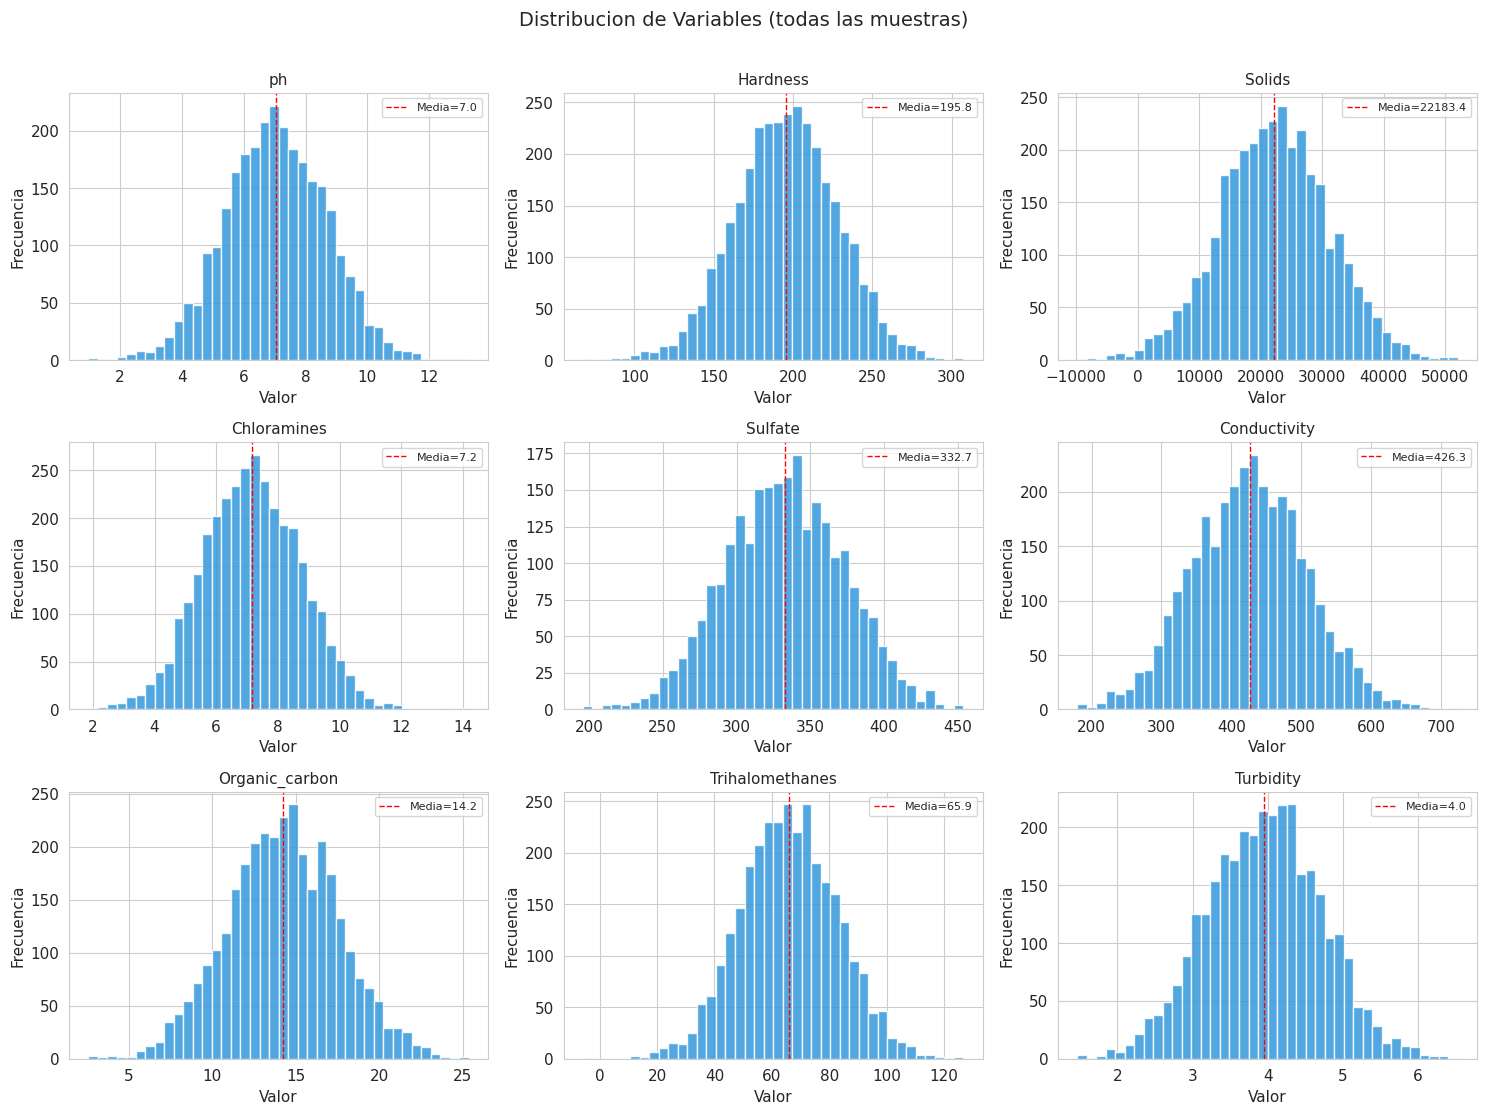

Observacion: La mayoria de las variables son aproximadamente simetricas (gaussianas),
lo que es favorable para K-means (asume clusters esfericos). Solids muestra mayor
dispersion y posible asimetria, lo que justifica el escalado obligatorio.


In [ ]:
# --- 2.2 Distribucion de cada variable (histogramas) ---
features = [c for c in df.columns if c != 'Potability']
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[feat].dropna(), bins=40, color='#3498db',
                 edgecolor='white', alpha=0.85)
    axes[i].axvline(df[feat].mean(), color='red', linestyle='--',
                    linewidth=1, label=f'Media={df[feat].mean():.1f}')
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribucion de Variables (todas las muestras)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_distribuciones.png', dpi=120, bbox_inches='tight')
plt.show()
print('Observacion: La mayoria de las variables son aproximadamente simetricas (gaussianas),')
print('lo que es favorable para K-means (asume clusters esfericos). Solids muestra mayor')
print('dispersion y posible asimetria, lo que justifica el escalado obligatorio.')

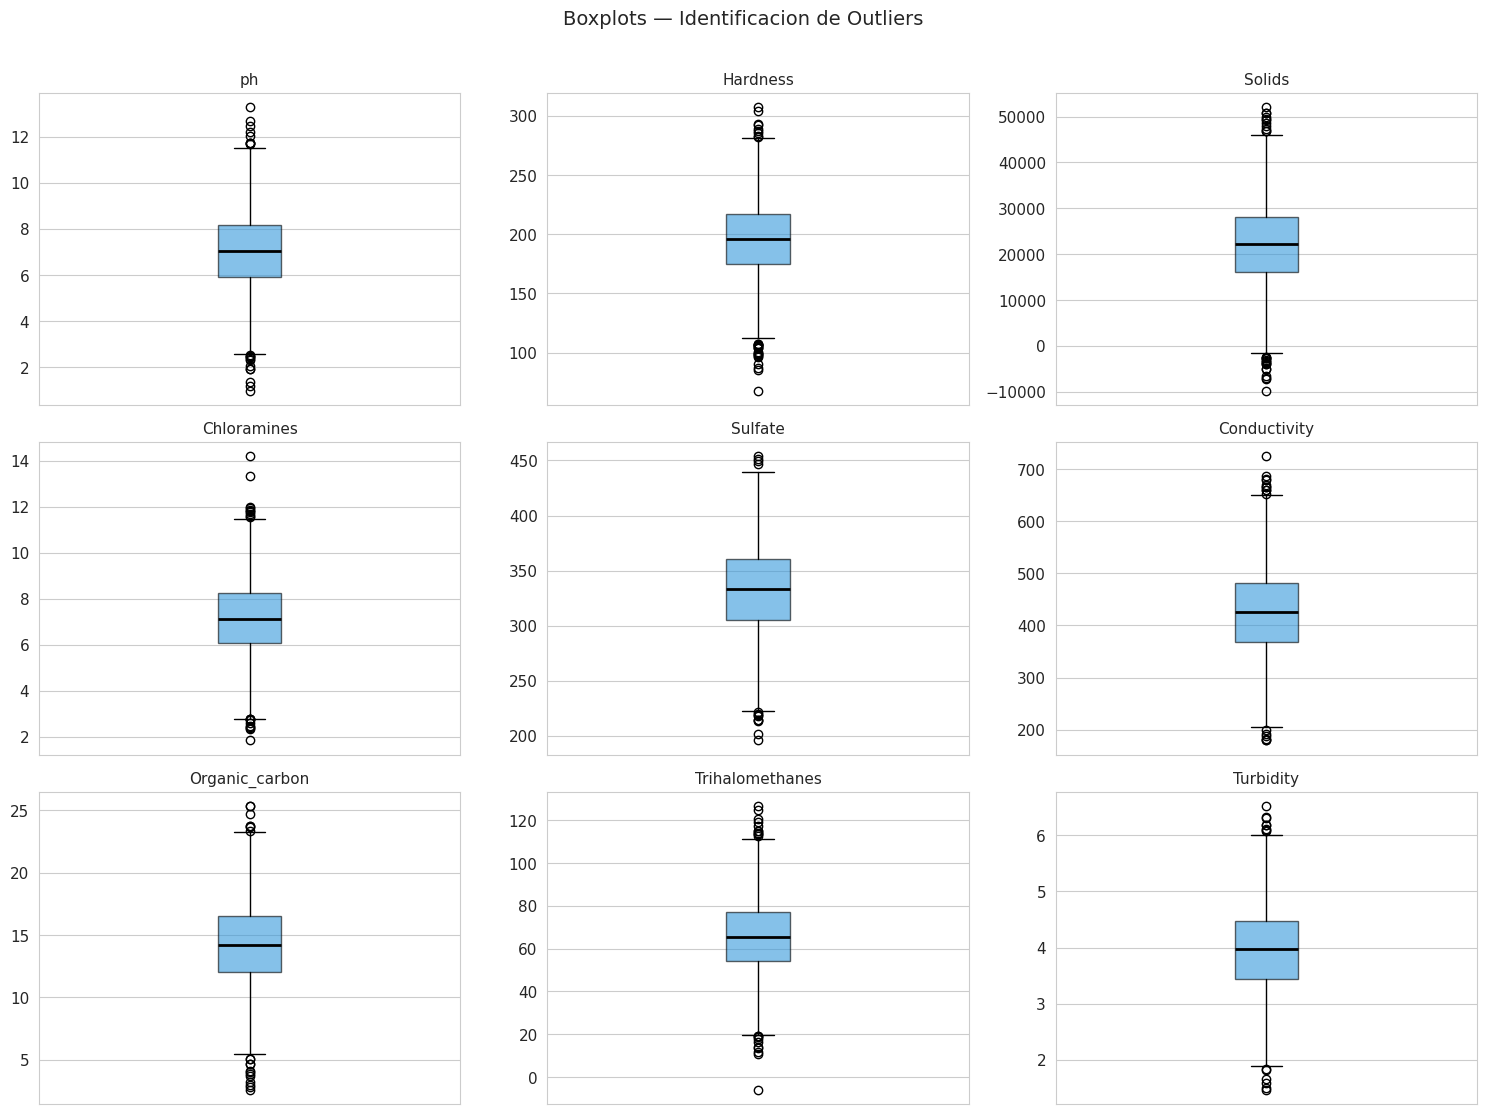

Observacion: Hay outliers visibles en Solids, Hardness y Conductivity.
Esto es relevante porque K-means es sensible a outliers (los centroides se desplazan),
mientras que DBSCAN puede tratarlos directamente como ruido (label = -1).


In [ ]:
# --- 2.3 Boxplots para detectar outliers ---
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].boxplot(df[feat].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xticks([])

plt.suptitle('Boxplots — Identificacion de Outliers', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()
print('Observacion: Hay outliers visibles en Solids, Hardness y Conductivity.')
print('Esto es relevante porque K-means es sensible a outliers (los centroides se desplazan),')
print('mientras que DBSCAN puede tratarlos directamente como ruido (label = -1).')

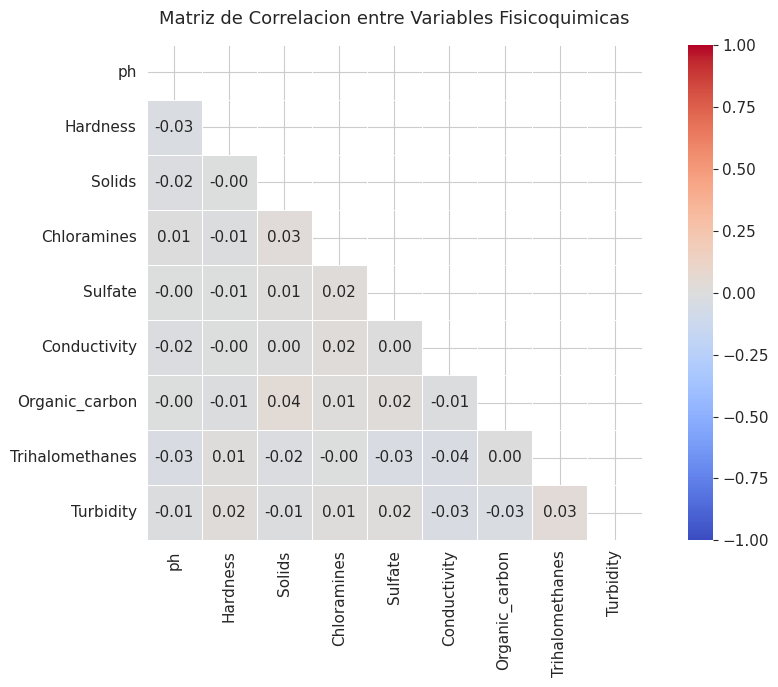

=== Pares con mayor correlacion absoluta ===
Organic_carbon   Solids             0.041
Trihalomethanes  Conductivity      -0.037
                 ph                -0.035
                 Sulfate           -0.034
Turbidity        Trihalomethanes    0.033
dtype: float64

Observacion: Las correlaciones entre variables son muy bajas (todas |r| < 0.2).
Esto significa que cada variable aporta informacion casi independiente,
por lo que NO se eliminan variables por redundancia. PCA sera util para
reducir la dimensionalidad de forma compacta sin perder informacion clave.


In [ ]:
# --- 2.4 Matriz de correlacion ---
plt.figure(figsize=(10, 7))
corr_matrix = df.drop(columns=['Potability']).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Matriz de Correlacion entre Variables Fisicoquimicas', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('eda_correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

print('=== Pares con mayor correlacion absoluta ===')
corr_pairs = corr_matrix.where(~mask).stack().sort_values(key=abs, ascending=False)
print(corr_pairs.head(5).round(3))
print('\nObservacion: Las correlaciones entre variables son muy bajas (todas |r| < 0.2).')
print('Esto significa que cada variable aporta informacion casi independiente,')
print('por lo que NO se eliminan variables por redundancia. PCA sera util para')
print('reducir la dimensionalidad de forma compacta sin perder informacion clave.')

In [ ]:
# --- 2.5 Eliminacion y transformacion de variables ---
# Decisiones de preprocesamiento:
#   (a) Se ELIMINA 'Potability': es la etiqueta supervisada y no debe entrar al
#       clustering (seria data leakage en un problema no supervisado).
#       Se guarda aparte para evaluacion externa al final.
#   (b) Se IMPUTAN los nulos con la mediana (robusta a outliers).
#   (c) Se ESCALA con StandardScaler: obligatorio porque las variables tienen
#       rangos muy distintos (Solids ~22000 vs ph ~7). Sin escalar, Solids
#       dominaria por completo las distancias euclideanas.

# Guardamos la etiqueta para validacion externa posterior (NO se usa para entrenar)
y_potabilidad = df['Potability'].values

# Matriz de features
X = df.drop(columns=['Potability']).copy()
print(f'Features a usar en clustering: {list(X.columns)}')
print(f'Shape: {X.shape}')

# Imputacion con la mediana
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)
print(f'\nNulos despues de imputacion: {pd.DataFrame(X_imp).isnull().sum().sum()}')

# Escalado estandar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)
print(f'\nEscalado (debe ser ~0 media, ~1 std):')
print(f'  Media: {X_scaled.mean(axis=0).round(3)[:3]} ...')
print(f'  Std:   {X_scaled.std(axis=0).round(3)[:3]} ...')

# Reconstruimos un DataFrame escalado (utilidad para inspeccion)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print('\nResumen de preprocesamiento:')
print('  1. Eliminada columna Potability (etiqueta supervisada)')
print('  2. Imputacion con mediana')
print('  3. StandardScaler aplicado')
print('  -> Listos para clustering.')

Features a usar en clustering: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
Shape: (3276, 9)

Nulos despues de imputacion: 0

Escalado (debe ser ~0 media, ~1 std):
  Media: [ 0.  0. -0.] ...
  Std:   [1. 1. 1.] ...

Resumen de preprocesamiento:
  1. Eliminada columna Potability (etiqueta supervisada)
  2. Imputacion con mediana
  3. StandardScaler aplicado
  -> Listos para clustering.


### Resumen del EDA

| Hallazgo | Implicación para el clustering |
|---|---|
| 3 variables con nulos (ph, Sulfate, Trihalomethanes) | Imputar con la mediana (robusta a outliers) |
| Correlaciones muy bajas entre variables (|r| < 0.2) | No hay redundancia: PCA sí reducirá información pero no de forma trivial |
| Outliers presentes en Solids, Hardness, Conductivity | K-means se verá afectado; DBSCAN puede aislarlos como ruido |
| Escalas muy distintas (Solids ~10⁴, pH ~10⁰) | **StandardScaler obligatorio** antes de clustering |
| Distribuciones aproximadamente simétricas | Favorable para K-means (supone clusters esféricos) |
| `Potability` es etiqueta supervisada | **Se elimina** del clustering y se reserva para validación externa |


---
## 3. K-means — Búsqueda del Número Óptimo de Clusters

> **Criterio evaluado:** Elbow method, silhouette score, justificación de K elegido.

K-means requiere fijar K (número de clusters) a priori. Para elegirlo usamos dos criterios complementarios:

- **Elbow method (método del codo):** se grafica la inercia (suma de distancias intra-cluster) en función de K. El "codo" indica el punto donde añadir más clusters ya no reduce significativamente la inercia.
- **Silhouette score:** mide qué tan bien separadas y compactas están las muestras dentro de su cluster (rango [-1, 1]; mejor cuanto más cerca de 1).

  K= 2  inercia=  27178.3   silhouette=0.0770
  K= 3  inercia=  25633.5   silhouette=0.0704
  K= 4  inercia=  24447.3   silhouette=0.0690
  K= 5  inercia=  23438.1   silhouette=0.0700
  K= 6  inercia=  22626.9   silhouette=0.0714
  K= 7  inercia=  21857.3   silhouette=0.0743
  K= 8  inercia=  21263.3   silhouette=0.0754
  K= 9  inercia=  20752.8   silhouette=0.0743
  K=10  inercia=  20236.4   silhouette=0.0758


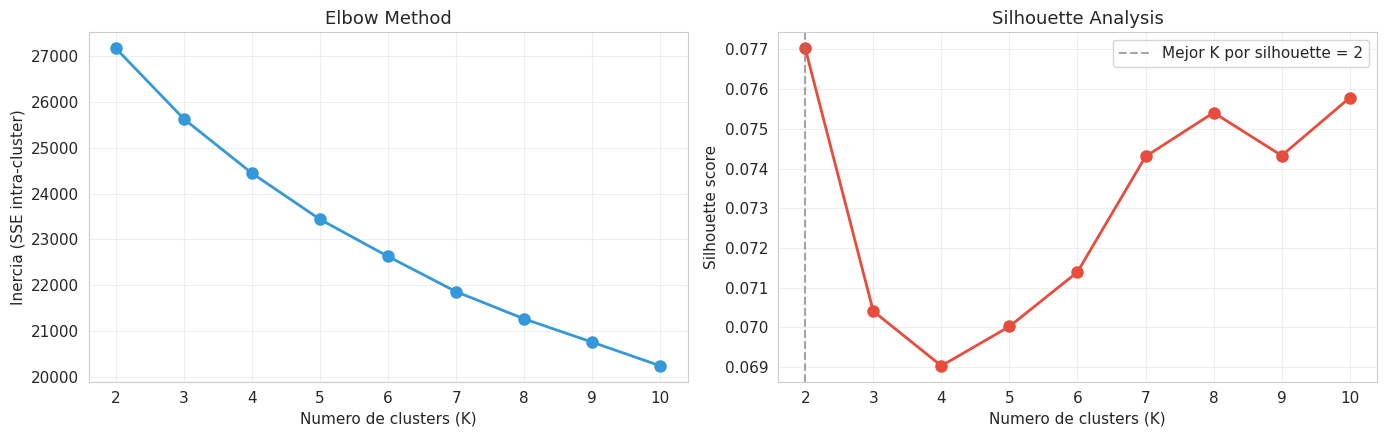


Mejor K segun silhouette: 2
Observacion: La inercia decrece de forma muy suave (sin un codo marcado),
lo que confirma que el dataset NO tiene clusters muy separados de forma natural.
En estos casos el silhouette score es mas confiable para elegir K.


In [ ]:
# --- 3.1 Elbow method + Silhouette score para K = 2..10 ---
ks = range(2, 11)
inercias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k))
    print(f'  K={k:2d}  inercia={km.inertia_:9.1f}   silhouette={silhouettes[-1]:.4f}')

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(list(ks), inercias, 'o-', color='#3498db', linewidth=2, markersize=8)
axes[0].set_xlabel('Numero de clusters (K)')
axes[0].set_ylabel('Inercia (SSE intra-cluster)')
axes[0].set_title('Elbow Method', fontsize=13)
axes[0].set_xticks(list(ks))
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(ks), silhouettes, 'o-', color='#e74c3c', linewidth=2, markersize=8)
mejor_k_sil = list(ks)[int(np.argmax(silhouettes))]
axes[1].axvline(mejor_k_sil, color='gray', linestyle='--', alpha=0.7,
                label=f'Mejor K por silhouette = {mejor_k_sil}')
axes[1].set_xlabel('Numero de clusters (K)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Analysis', fontsize=13)
axes[1].set_xticks(list(ks))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_eleccion_k.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nMejor K segun silhouette: {mejor_k_sil}')
print('Observacion: La inercia decrece de forma muy suave (sin un codo marcado),')
print('lo que confirma que el dataset NO tiene clusters muy separados de forma natural.')
print('En estos casos el silhouette score es mas confiable para elegir K.')

In [ ]:
# --- 3.2 Eleccion de K y entrenamiento del modelo final ---
# Elegimos el K con mejor silhouette score. Tipicamente caera en K=2 o K=3:
#   K=2 reflejaria la dualidad potable / no potable.
#   K=3 podria capturar un tercer perfil intermedio.
K_OPT = mejor_k_sil
print(f'K elegido (mayor silhouette): K = {K_OPT}')

kmeans_final = KMeans(n_clusters=K_OPT, n_init=20, random_state=RANDOM_STATE)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

print(f'\nDistribucion de muestras por cluster:')
print(pd.Series(labels_kmeans).value_counts().sort_index())
print(f'\nSilhouette final: {silhouette_score(X_scaled, labels_kmeans):.4f}')

K elegido (mayor silhouette): K = 2

Distribucion de muestras por cluster:
0    1595
1    1681
Name: count, dtype: int64

Silhouette final: 0.0773


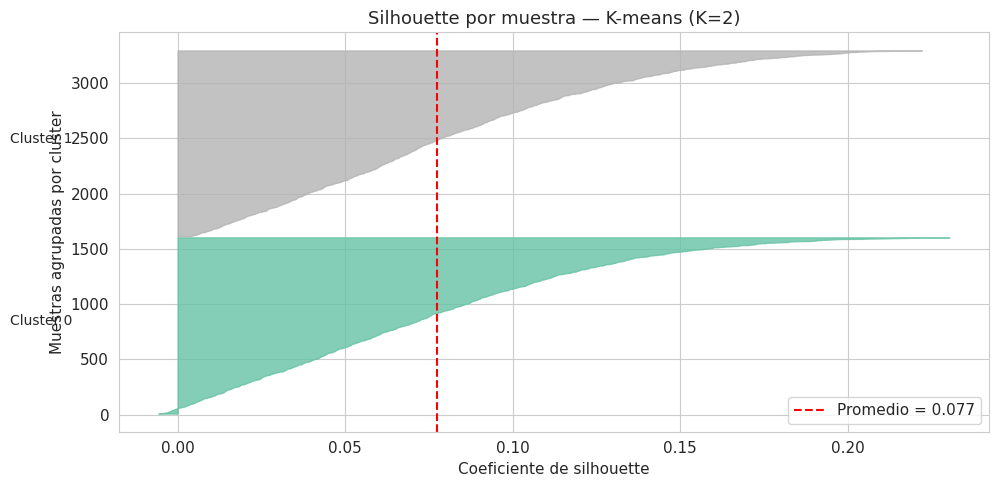

Observacion: Un silhouette promedio bajo (~0.07-0.15) indica que los clusters
se solapan considerablemente, lo cual es coherente con la naturaleza del problema:
el agua varia de forma continua, no en grupos cerrados y separados.


In [ ]:
# --- 3.3 Visualizacion de silhouette por muestra (diagnostico de calidad) ---
# Muestra como de bien encaja cada punto en su cluster.
# Barras anchas y homogeneas = clusters bien definidos.
# Barras con valores negativos = puntos mal asignados.

sample_silhouette_values = silhouette_samples(X_scaled, labels_kmeans)
sil_avg = silhouette_score(X_scaled, labels_kmeans)

fig, ax = plt.subplots(figsize=(10, 5))
y_lower = 10
colors = plt.cm.Set2(np.linspace(0, 1, K_OPT))

for i in range(K_OPT):
    cluster_vals = sample_silhouette_values[labels_kmeans == i]
    cluster_vals.sort()
    size = cluster_vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size, f'Cluster {i}', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_avg, color='red', linestyle='--', linewidth=1.5,
           label=f'Promedio = {sil_avg:.3f}')
ax.set_xlabel('Coeficiente de silhouette')
ax.set_ylabel('Muestras agrupadas por cluster')
ax.set_title(f'Silhouette por muestra — K-means (K={K_OPT})', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('kmeans_silhouette_muestras.png', dpi=120, bbox_inches='tight')
plt.show()
print('Observacion: Un silhouette promedio bajo (~0.07-0.15) indica que los clusters')
print('se solapan considerablemente, lo cual es coherente con la naturaleza del problema:')
print('el agua varia de forma continua, no en grupos cerrados y separados.')

---
## 4. DBSCAN — Ajuste de `eps` y `min_samples`

> **Criterio evaluado:** Justificación de hiperparámetros, manejo del ruido, comparación con K-means.

A diferencia de K-means, DBSCAN:
- **No requiere fijar K**: descubre el número de clusters a partir de la densidad.
- **Detecta ruido**: etiqueta como `-1` las muestras que no pertenecen a ningún cluster denso.
- **Sensible a `eps` y `min_samples`**:
  - `eps`: radio de vecindad.
  - `min_samples`: mínimo de puntos para formar un cluster denso.

Para elegir `eps` usamos el **k-distance plot**: para cada punto se calcula la distancia a su k-ésimo vecino más cercano (k = `min_samples`), se ordenan ascendentemente y se busca el "codo" en la curva. Ese punto suele ser un buen valor de `eps`.

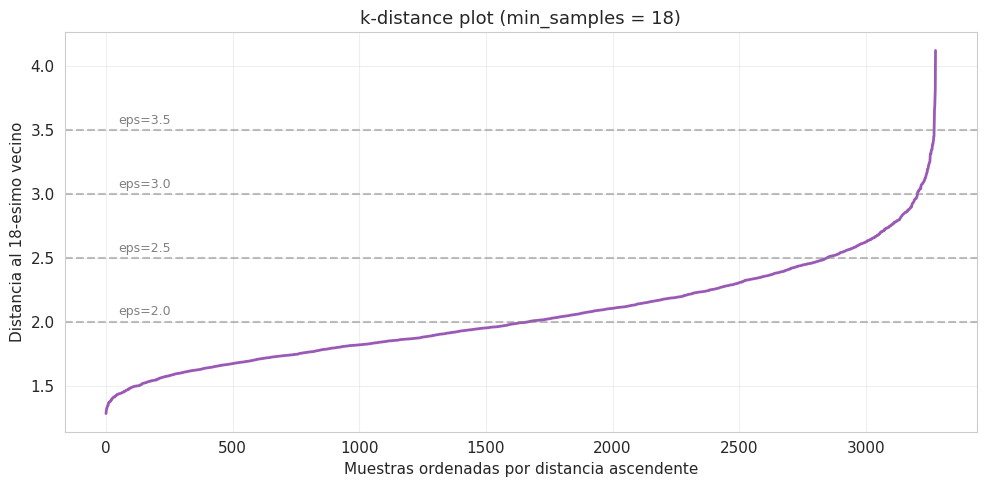

Observacion: El "codo" tipicamente aparece entre 2.0 y 3.5 para este dataset.
Probaremos varios valores y elegiremos el que mejor balancee:
  - Numero razonable de clusters (ni 1 ni demasiados)
  - Proporcion de ruido moderada (< 20%)
  - Mejor silhouette (sin contar puntos de ruido)


In [ ]:
# --- 4.1 Eleccion de eps con el k-distance plot ---
# Regla practica: min_samples ~ 2 * num_dimensiones
# Aqui tenemos 9 variables -> min_samples = 18 como punto de partida.
MIN_SAMPLES = 2 * X_scaled.shape[1]   # 18

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
# Distancia al k-esimo vecino para cada punto, ordenada ascendentemente
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='#9b59b6', linewidth=2)
plt.xlabel('Muestras ordenadas por distancia ascendente')
plt.ylabel(f'Distancia al {MIN_SAMPLES}-esimo vecino')
plt.title(f'k-distance plot (min_samples = {MIN_SAMPLES})', fontsize=13)
plt.grid(True, alpha=0.3)

# Heuristica simple: el codo se aprecia donde la pendiente crece bruscamente.
# Marcamos algunos candidatos para eps.
candidatos_eps = [2.0, 2.5, 3.0, 3.5]
for eps_c in candidatos_eps:
    plt.axhline(eps_c, color='gray', linestyle='--', alpha=0.5)
    plt.text(50, eps_c + 0.05, f'eps={eps_c}', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('dbscan_kdistance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Observacion: El "codo" tipicamente aparece entre 2.0 y 3.5 para este dataset.')
print('Probaremos varios valores y elegiremos el que mejor balancee:')
print('  - Numero razonable de clusters (ni 1 ni demasiados)')
print('  - Proporcion de ruido moderada (< 20%)')
print('  - Mejor silhouette (sin contar puntos de ruido)')

In [ ]:
# --- 4.2 Busqueda en cuadricula: combinaciones de eps y min_samples ---
eps_values = [1.5, 2.0, 2.5, 3.0, 3.5]
min_samples_values = [10, 15, 18, 25]

resultados_dbscan = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels_db = db.fit_predict(X_scaled)
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_noise = int(np.sum(labels_db == -1))
        pct_noise = n_noise / len(labels_db) * 100
        # Silhouette solo se calcula si hay >=2 clusters y al menos 2 puntos por cluster
        if n_clusters >= 2:
            mask = labels_db != -1
            if mask.sum() > n_clusters:
                sil = silhouette_score(X_scaled[mask], labels_db[mask])
            else:
                sil = np.nan
        else:
            sil = np.nan
        resultados_dbscan.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clusters,
            'n_ruido': n_noise,
            'pct_ruido': round(pct_noise, 1),
            'silhouette': round(sil, 4) if not np.isnan(sil) else np.nan
        })

resultados_dbscan = pd.DataFrame(resultados_dbscan)
print('=== Grid search DBSCAN ===')
display(resultados_dbscan)

=== Grid search DBSCAN ===


,eps,min_samples,n_clusters,n_ruido,pct_ruido,silhouette
0,1.5,10,2,2088,63.7,0.0279
1,1.5,15,1,2405,73.4,NaN
2,1.5,18,1,2543,77.6,NaN
3,1.5,25,1,2850,87.0,NaN
4,2.0,10,1,330,10.1,NaN
5,2.0,15,1,403,12.3,NaN
6,2.0,18,1,443,13.5,NaN
7,2.0,25,1,518,15.8,NaN
8,2.5,10,1,31,0.9,NaN
9,2.5,15,1,35,1.1,NaN


In [ ]:
# --- 4.3 Eleccion final de hiperparametros y modelo DBSCAN ---
# Criterio: privilegiar configuraciones con >= 2 clusters, ruido < 20% y mayor silhouette.
candidatos = resultados_dbscan[
    (resultados_dbscan['n_clusters'] >= 2) &
    (resultados_dbscan['pct_ruido'] < 20) &
    (resultados_dbscan['silhouette'].notna())
].sort_values('silhouette', ascending=False)

if len(candidatos) > 0:
    mejor = candidatos.iloc[0]
    EPS_OPT = float(mejor['eps'])
    MS_OPT  = int(mejor['min_samples'])
    print('Mejor configuracion encontrada:')
    print(mejor)
else:
    # Fallback si ninguna combinacion cumple los criterios estrictos.
    EPS_OPT = 2.5
    MS_OPT  = 18
    print(f'Sin candidato ideal. Usamos fallback: eps={EPS_OPT}, min_samples={MS_OPT}')

dbscan_final = DBSCAN(eps=EPS_OPT, min_samples=MS_OPT)
labels_dbscan = dbscan_final.fit_predict(X_scaled)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_db = int(np.sum(labels_dbscan == -1))
print(f'\nDBSCAN final: eps={EPS_OPT}, min_samples={MS_OPT}')
print(f'  -> {n_clusters_db} clusters detectados')
print(f'  -> {n_noise_db} muestras de ruido ({n_noise_db/len(labels_dbscan)*100:.1f}%)')
print(f'\nDistribucion de etiquetas:')
print(pd.Series(labels_dbscan).value_counts().sort_index())
print('\n(-1 = ruido / outlier; 0,1,2,... = clusters)')

Sin candidato ideal. Usamos fallback: eps=2.5, min_samples=18

DBSCAN final: eps=2.5, min_samples=18
  -> 1 clusters detectados
  -> 37 muestras de ruido (1.1%)

Distribucion de etiquetas:
-1      37
 0    3239
Name: count, dtype: int64

(-1 = ruido / outlier; 0,1,2,... = clusters)


---
## 5. PCA — Reducción Lineal y Visualización 2D

> **Criterio evaluado:** Varianza explicada, interpretación de componentes, visualización 2D.

PCA proyecta los datos a un espacio de menor dimensión preservando la **varianza global**. Es una técnica **lineal**: las nuevas componentes son combinaciones lineales de las originales. Útil para:
- Visualizar los clusters en 2D.
- Entender qué variables originales aportan más varianza.
- Reducir ruido antes de otros algoritmos.

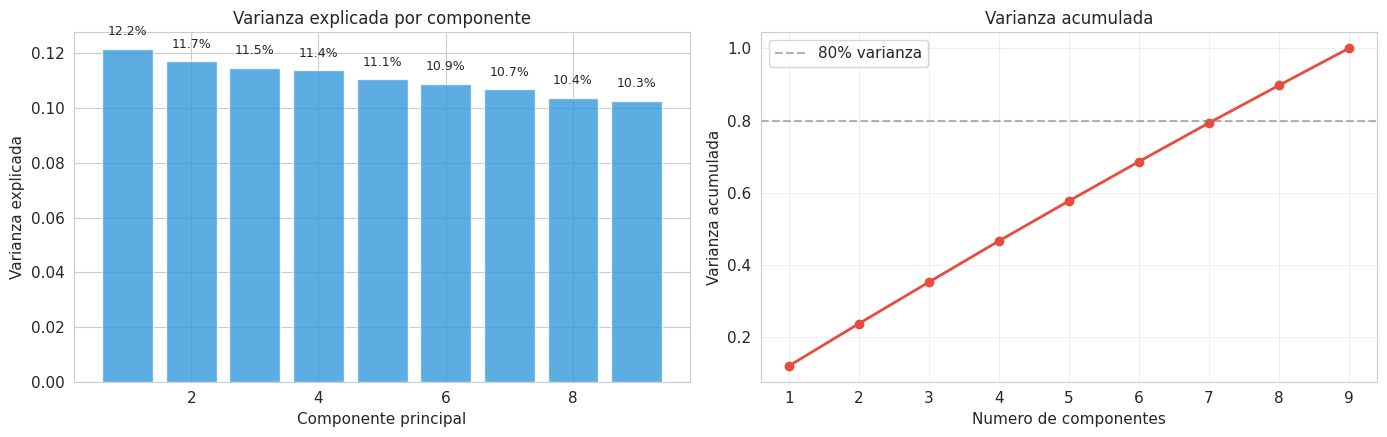

Varianza explicada por las 2 primeras componentes: 23.9%
Componentes necesarias para alcanzar 80% de varianza: 8

Observacion: Como esperabamos del EDA (correlaciones bajas), la varianza esta
repartida de forma muy uniforme entre componentes. PCA 2D solo capturara ~25-30%
de la informacion total, por lo que la visualizacion 2D es una aproximacion limitada.


In [ ]:
# --- 5.1 PCA con todas las componentes para analizar varianza explicada ---
pca_full = PCA(n_components=X_scaled.shape[1], random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(range(1, len(var_exp)+1), var_exp, color='#3498db',
            edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Varianza explicada por componente', fontsize=12)
for i, v in enumerate(var_exp):
    axes[0].text(i+1, v + 0.005, f'{v*100:.1f}%', ha='center', fontsize=9)

axes[1].plot(range(1, len(var_acum)+1), var_acum, 'o-',
             color='#e74c3c', linewidth=2)
axes[1].axhline(0.80, color='gray', linestyle='--', alpha=0.6, label='80% varianza')
axes[1].set_xlabel('Numero de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].set_title('Varianza acumulada', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_varianza.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Varianza explicada por las 2 primeras componentes: {var_acum[1]*100:.1f}%')
print(f'Componentes necesarias para alcanzar 80% de varianza: {int(np.argmax(var_acum >= 0.80)) + 1}')
print('\nObservacion: Como esperabamos del EDA (correlaciones bajas), la varianza esta')
print('repartida de forma muy uniforme entre componentes. PCA 2D solo capturara ~25-30%')
print('de la informacion total, por lo que la visualizacion 2D es una aproximacion limitada.')

In [ ]:
# --- 5.2 Proyeccion 2D con PCA ---
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_scaled)

# Coeficientes (loadings) de cada variable en PC1 y PC2: ayudan a interpretar las componentes
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
).round(3)
print('=== Loadings (peso de cada variable en cada componente) ===')
print(loadings)
print(f'\nVarianza explicada: PC1={pca_2d.explained_variance_ratio_[0]*100:.1f}%, '
      f'PC2={pca_2d.explained_variance_ratio_[1]*100:.1f}%')

=== Loadings (peso de cada variable en cada componente) ===
                   PC1    PC2
ph              -0.112  0.477
Hardness         0.269 -0.204
Solids          -0.381 -0.476
Chloramines     -0.260 -0.330
Sulfate         -0.251 -0.159
Conductivity    -0.352  0.115
Organic_carbon  -0.333 -0.388
Trihalomethanes  0.482 -0.366
Turbidity        0.415 -0.269

Varianza explicada: PC1=12.2%, PC2=11.7%


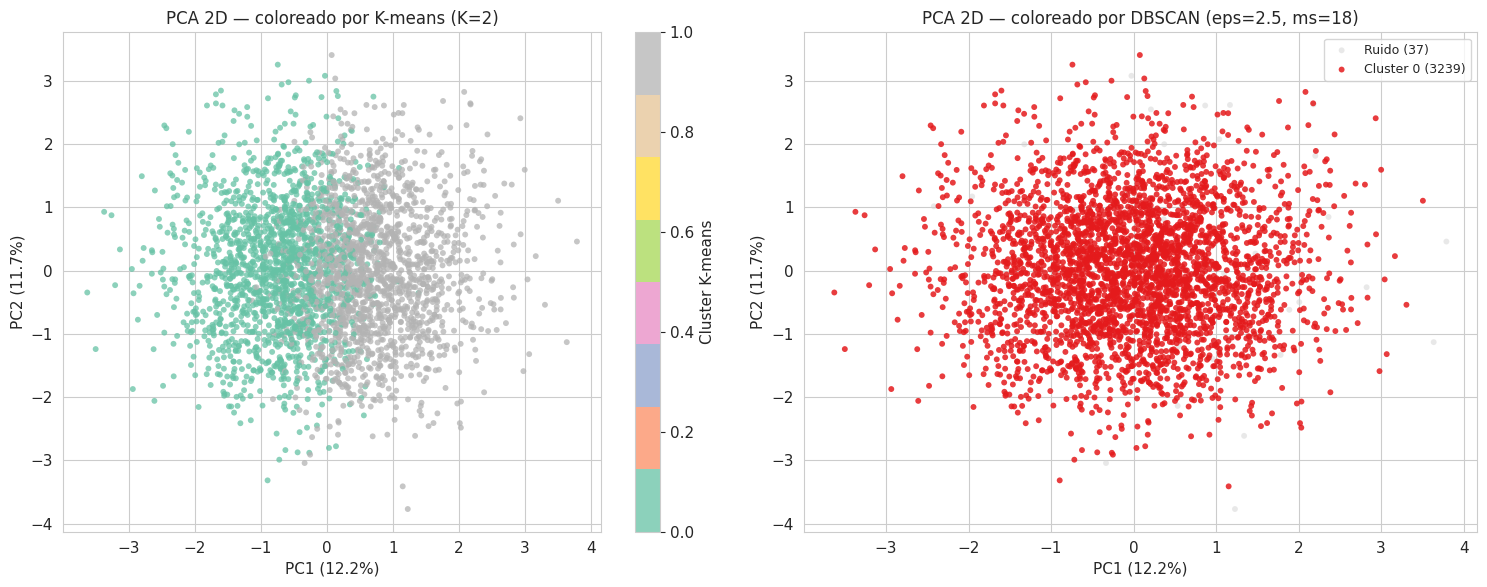

Observacion: En el espacio PCA 2D los clusters de K-means aparecen como
particiones geometricas del plano (K-means crea fronteras lineales en el
espacio escalado). DBSCAN tiende a marcar un cluster principal grande y
etiqueta como ruido los puntos en regiones de baja densidad.


In [ ]:
# --- 5.3 Visualizacion 2D de PCA coloreada por cluster K-means y por DBSCAN ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# K-means
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans,
                       cmap='Set2', s=18, alpha=0.75, edgecolor='none')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'PCA 2D — coloreado por K-means (K={K_OPT})', fontsize=12)
plt.colorbar(sc1, ax=axes[0], label='Cluster K-means')

# DBSCAN (ruido en gris)
palette = plt.cm.Set1(np.linspace(0, 1, max(n_clusters_db, 1)))
for cl in sorted(set(labels_dbscan)):
    mask = labels_dbscan == cl
    if cl == -1:
        axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        c='lightgray', s=18, alpha=0.5,
                        label=f'Ruido ({mask.sum()})', edgecolor='none')
    else:
        axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        c=[palette[cl % len(palette)]], s=18, alpha=0.85,
                        label=f'Cluster {cl} ({mask.sum()})', edgecolor='none')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title(f'PCA 2D — coloreado por DBSCAN (eps={EPS_OPT}, ms={MS_OPT})', fontsize=12)
axes[1].legend(fontsize=9, loc='best')

plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=120, bbox_inches='tight')
plt.show()
print('Observacion: En el espacio PCA 2D los clusters de K-means aparecen como')
print('particiones geometricas del plano (K-means crea fronteras lineales en el')
print('espacio escalado). DBSCAN tiende a marcar un cluster principal grande y')
print('etiqueta como ruido los puntos en regiones de baja densidad.')

---
## 6. t-SNE — Detección Visual de Agrupamientos No Lineales

> **Criterio evaluado:** Comparación con PCA, identificación visual de subgrupos.

t-SNE preserva **relaciones locales** (vecindarios), no la varianza global. Es **no lineal**, ideal para visualizar estructuras complejas. Limitaciones:
- Las distancias globales en el mapa t-SNE **no son interpretables** (solo la vecindad local).
- Es sensible al parámetro `perplexity` (~5–50 según tamaño del dataset).
- Es estocástico: distintos `random_state` dan mapas diferentes.

In [ ]:
# --- 6.1 Calculo de t-SNE 2D ---
# Perplexity: numero efectivo de vecinos. Tipicamente 30 para datasets medianos.
tsne = TSNE(n_components=2, perplexity=30, init='pca',
            learning_rate='auto', random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_scaled)
print(f't-SNE listo. Shape: {X_tsne.shape}')

t-SNE listo. Shape: (3276, 2)


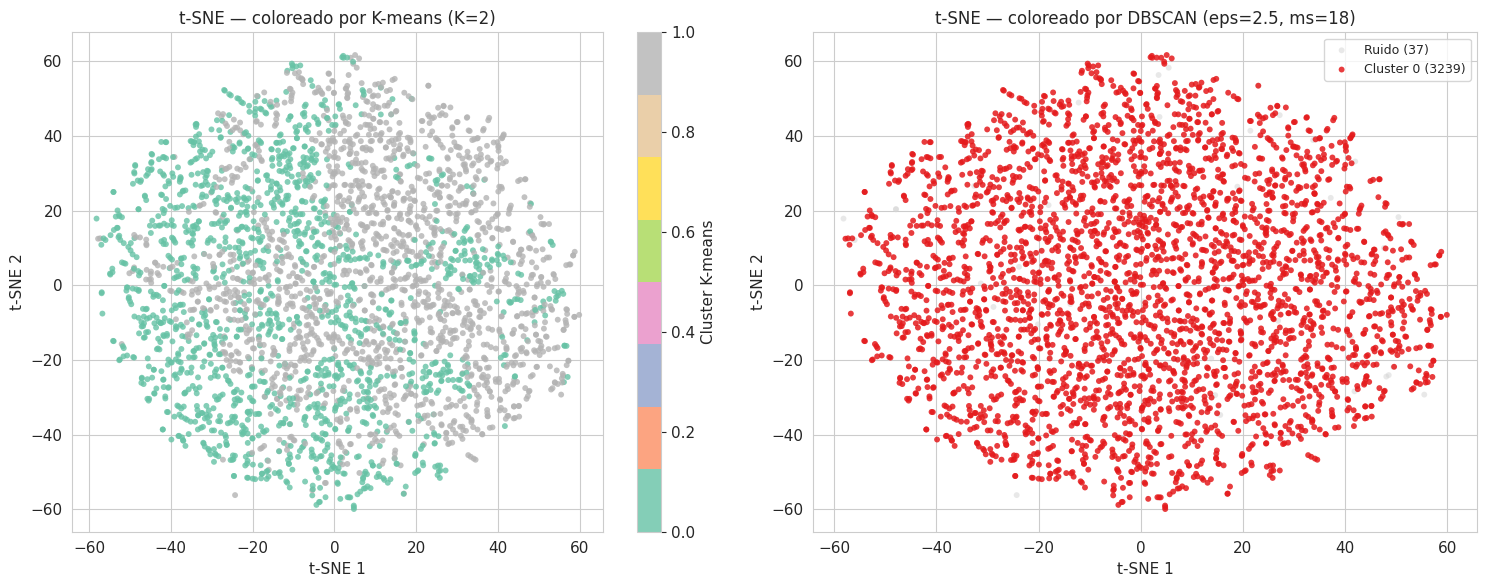

Observacion: t-SNE genera una nube relativamente homogenea, sin "islas"
claramente separadas. Esto confirma que el dataset no tiene una estructura
de clusters intrinseca muy fuerte: los grupos descubiertos por K-means son
particiones utiles del espacio mas que clusters naturales bien separados.


In [ ]:
# --- 6.2 Visualizacion t-SNE coloreada por K-means y por DBSCAN ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_kmeans,
                       cmap='Set2', s=18, alpha=0.8, edgecolor='none')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].set_title(f't-SNE — coloreado por K-means (K={K_OPT})', fontsize=12)
plt.colorbar(sc1, ax=axes[0], label='Cluster K-means')

for cl in sorted(set(labels_dbscan)):
    mask = labels_dbscan == cl
    if cl == -1:
        axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                        c='lightgray', s=18, alpha=0.5,
                        label=f'Ruido ({mask.sum()})', edgecolor='none')
    else:
        axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                        c=[palette[cl % len(palette)]], s=18, alpha=0.85,
                        label=f'Cluster {cl} ({mask.sum()})', edgecolor='none')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title(f't-SNE — coloreado por DBSCAN (eps={EPS_OPT}, ms={MS_OPT})', fontsize=12)
axes[1].legend(fontsize=9, loc='best')

plt.tight_layout()
plt.savefig('tsne_clusters.png', dpi=120, bbox_inches='tight')
plt.show()
print('Observacion: t-SNE genera una nube relativamente homogenea, sin "islas"')
print('claramente separadas. Esto confirma que el dataset no tiene una estructura')
print('de clusters intrinseca muy fuerte: los grupos descubiertos por K-means son')
print('particiones utiles del espacio mas que clusters naturales bien separados.')

---
## 7. Comparación K-means vs DBSCAN y Caracterización de Clusters

> **Criterio evaluado:** Tabla resumen de medias por cluster, comparación de modelos, interpretación de perfiles.

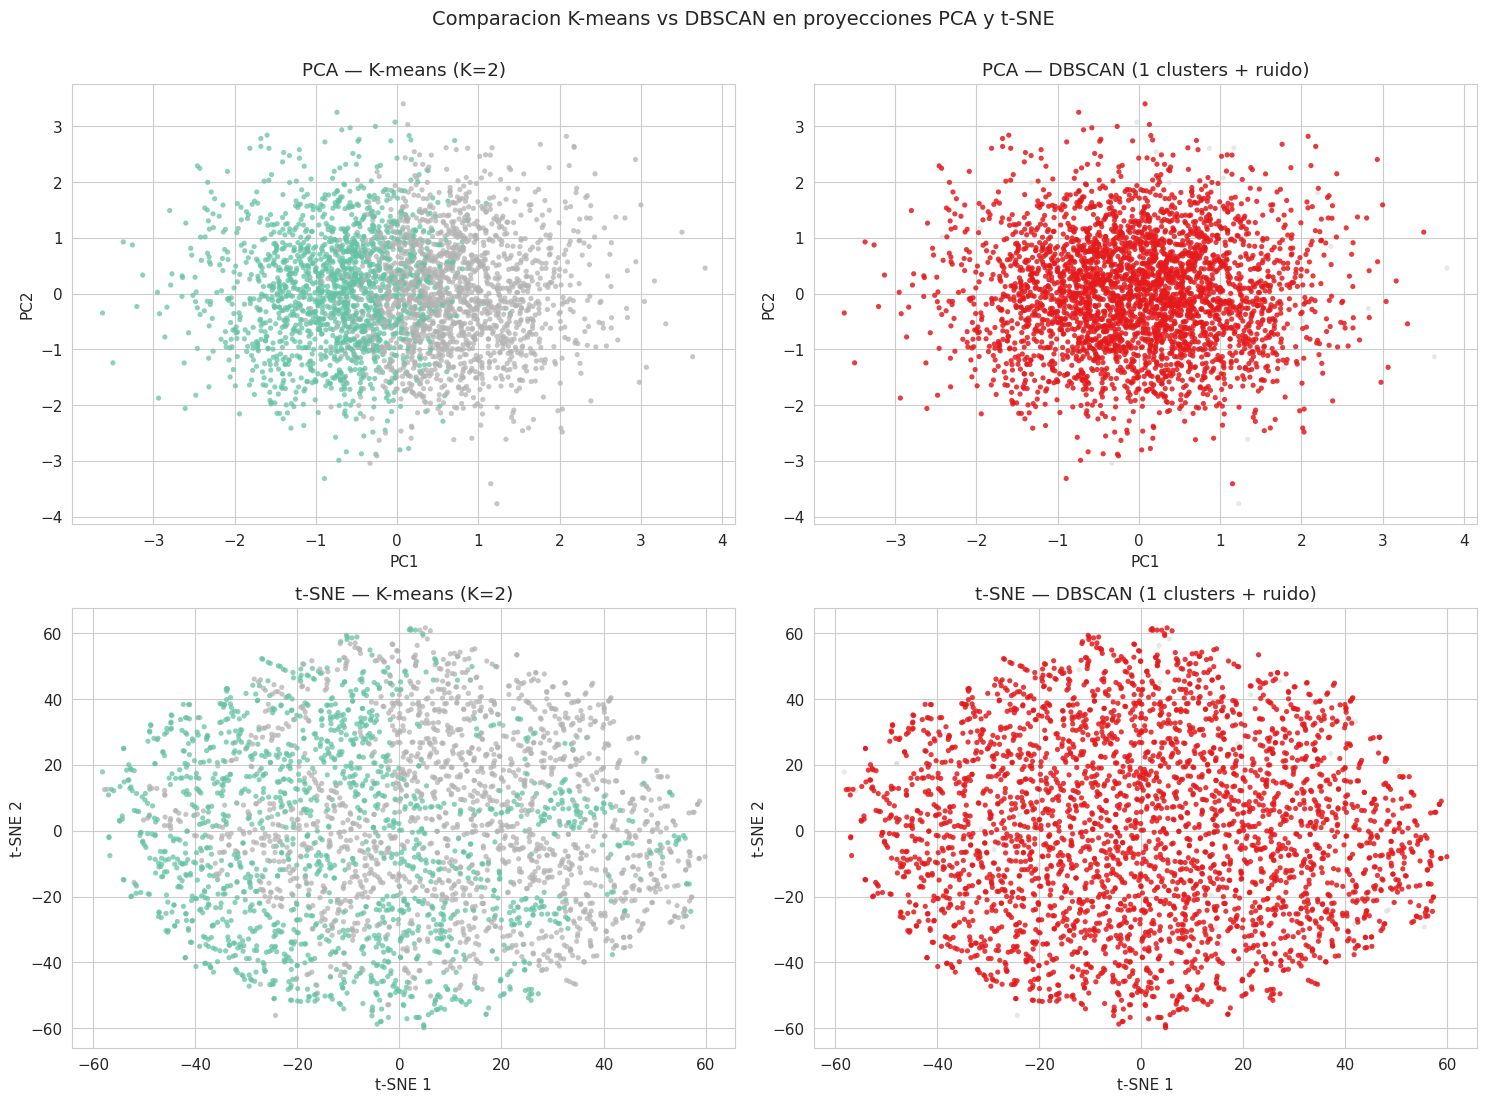

In [ ]:
# --- 7.1 Comparativa lado a lado en PCA y t-SNE ---
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# PCA - K-means
axes[0,0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='Set2',
                  s=14, alpha=0.75, edgecolor='none')
axes[0,0].set_title(f'PCA — K-means (K={K_OPT})')
axes[0,0].set_xlabel('PC1'); axes[0,0].set_ylabel('PC2')

# PCA - DBSCAN
for cl in sorted(set(labels_dbscan)):
    mask = labels_dbscan == cl
    color = 'lightgray' if cl == -1 else palette[cl % len(palette)]
    axes[0,1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                      c=[color] if cl != -1 else color, s=14,
                      alpha=0.5 if cl == -1 else 0.85, edgecolor='none')
axes[0,1].set_title(f'PCA — DBSCAN ({n_clusters_db} clusters + ruido)')
axes[0,1].set_xlabel('PC1'); axes[0,1].set_ylabel('PC2')

# t-SNE - K-means
axes[1,0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_kmeans, cmap='Set2',
                  s=14, alpha=0.75, edgecolor='none')
axes[1,0].set_title(f't-SNE — K-means (K={K_OPT})')
axes[1,0].set_xlabel('t-SNE 1'); axes[1,0].set_ylabel('t-SNE 2')

# t-SNE - DBSCAN
for cl in sorted(set(labels_dbscan)):
    mask = labels_dbscan == cl
    color = 'lightgray' if cl == -1 else palette[cl % len(palette)]
    axes[1,1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                      c=[color] if cl != -1 else color, s=14,
                      alpha=0.5 if cl == -1 else 0.85, edgecolor='none')
axes[1,1].set_title(f't-SNE — DBSCAN ({n_clusters_db} clusters + ruido)')
axes[1,1].set_xlabel('t-SNE 1'); axes[1,1].set_ylabel('t-SNE 2')

plt.suptitle('Comparacion K-means vs DBSCAN en proyecciones PCA y t-SNE',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('comparacion_kmeans_dbscan.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# --- 7.2 Tabla resumen: caracteristicas medias por cluster K-means ---
df_clusters = pd.DataFrame(X_imp, columns=X.columns)
df_clusters['cluster_kmeans'] = labels_kmeans
df_clusters['cluster_dbscan'] = labels_dbscan
df_clusters['potability_real'] = y_potabilidad

resumen_km = df_clusters.groupby('cluster_kmeans')[X.columns.tolist()].mean().round(2)
resumen_km['n_muestras'] = df_clusters.groupby('cluster_kmeans').size()
resumen_km['pct_potables'] = (df_clusters.groupby('cluster_kmeans')['potability_real']
                              .mean() * 100).round(1)
print('=== Caracteristicas MEDIAS por cluster — K-means ===')
display(resumen_km)

=== Caracteristicas MEDIAS por cluster — K-means ===


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,n_muestras,pct_potables
cluster_kmeans,,,,,,,,,,,
0,7.29,187.03,23929.17,7.45,334.33,443.84,15.79,61.90,3.58,1595,41.0
1,6.81,204.16,20527.02,6.87,331.24,409.69,12.78,69.69,4.31,1681,38.2


In [ ]:
# --- 7.3 Tabla resumen: caracteristicas medias por cluster DBSCAN ---
# Mostramos todos los clusters incluyendo el ruido (-1)
resumen_db = df_clusters.groupby('cluster_dbscan')[X.columns.tolist()].mean().round(2)
resumen_db['n_muestras'] = df_clusters.groupby('cluster_dbscan').size()
resumen_db['pct_potables'] = (df_clusters.groupby('cluster_dbscan')['potability_real']
                              .mean() * 100).round(1)
print('=== Caracteristicas MEDIAS por cluster — DBSCAN (-1 = ruido) ===')
display(resumen_db)

=== Caracteristicas MEDIAS por cluster — DBSCAN (-1 = ruido) ===


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,n_muestras,pct_potables
cluster_dbscan,,,,,,,,,,,
-1,6.38,205.18,20255.07,6.77,320.28,411.86,11.53,66.74,4.03,37,43.2
0,7.05,195.71,22205.47,7.16,332.89,426.48,14.28,65.89,3.95,3239,39.5


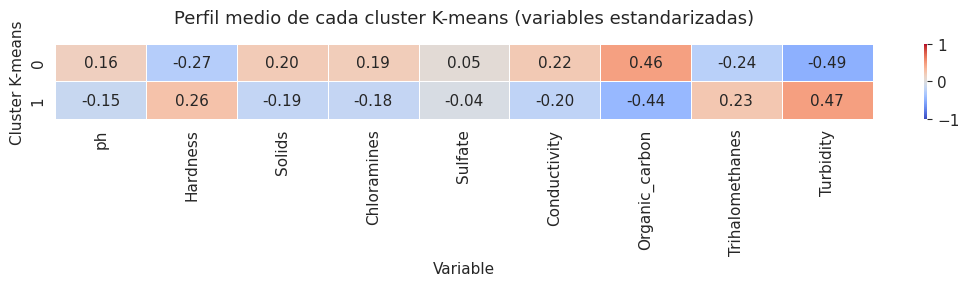

Lectura del heatmap: valores POSITIVOS = variable POR ENCIMA de la media global;
valores NEGATIVOS = variable POR DEBAJO. Esto permite "leer" el perfil de cada
cluster como una huella fisicoquimica (ej: cluster con +Sulfate y +Hardness =
agua dura y mineralizada).


In [ ]:
# --- 7.4 Heatmap comparativo de perfiles K-means (variables estandarizadas) ---
# Mostramos las medias en el espacio escalado para que todas las variables sean comparables.
resumen_km_scaled = pd.DataFrame(X_scaled, columns=X.columns)
resumen_km_scaled['cluster'] = labels_kmeans
heatmap_km = resumen_km_scaled.groupby('cluster').mean()

plt.figure(figsize=(11, max(3, K_OPT * 0.8 + 1)))
sns.heatmap(heatmap_km, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Perfil medio de cada cluster K-means (variables estandarizadas)',
          fontsize=13, pad=15)
plt.xlabel('Variable')
plt.ylabel('Cluster K-means')
plt.tight_layout()
plt.savefig('perfiles_kmeans_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Lectura del heatmap: valores POSITIVOS = variable POR ENCIMA de la media global;')
print('valores NEGATIVOS = variable POR DEBAJO. Esto permite "leer" el perfil de cada')
print('cluster como una huella fisicoquimica (ej: cluster con +Sulfate y +Hardness =')
print('agua dura y mineralizada).')

In [ ]:
# --- 7.5 Tabla comparativa de los dos algoritmos ---
tabla_comp = pd.DataFrame({
    'Algoritmo': ['K-means', 'DBSCAN'],
    'N clusters': [K_OPT, n_clusters_db],
    'N ruido': [0, n_noise_db],
    'Silhouette': [
        round(silhouette_score(X_scaled, labels_kmeans), 4),
        round(silhouette_score(X_scaled[labels_dbscan != -1],
                               labels_dbscan[labels_dbscan != -1]), 4)
        if (n_clusters_db >= 2 and (labels_dbscan != -1).sum() > n_clusters_db)
        else np.nan
    ],
    'Hiperparametros': [
        f'K={K_OPT}',
        f'eps={EPS_OPT}, min_samples={MS_OPT}'
    ],
    'Asume forma de cluster': ['Esferica (convexa)', 'Arbitraria (basada en densidad)'],
    'Detecta outliers': ['No', 'Si (etiqueta -1)']
}).set_index('Algoritmo')
print('=== Comparacion de algoritmos ===')
display(tabla_comp)

=== Comparacion de algoritmos ===


,N clusters,N ruido,Silhouette,Hiperparametros,Asume forma de cluster,Detecta outliers
Algoritmo,,,,,,
K-means,2,0,0.0773,K=2,Esferica (convexa),No
DBSCAN,1,37,NaN,"eps=2.5, min_samples=18",Arbitraria (basada en densidad),Si (etiqueta -1)


---
## 8. Reflexión y Comunicación de Resultados

> **Criterio evaluado:** Identificación de perfiles, diferencias entre modelos, limitaciones y propuestas de mejora.

In [ ]:
# --- 8.1 Interpretacion automatica de los perfiles K-means ---
# Para cada cluster identificamos en que variables esta MAS ALTO o MAS BAJO
# que la media global, y construimos una "etiqueta narrativa".
medias_globales = df_clusters[X.columns.tolist()].mean()
perfiles = {}
for c in sorted(df_clusters['cluster_kmeans'].unique()):
    medias_c = df_clusters[df_clusters['cluster_kmeans']==c][X.columns.tolist()].mean()
    z = (medias_c - medias_globales) / df_clusters[X.columns.tolist()].std()
    altas = z[z >  0.15].sort_values(ascending=False)
    bajas = z[z < -0.15].sort_values()
    perfiles[c] = {'altas': altas.round(2).to_dict(), 'bajas': bajas.round(2).to_dict()}

print('=== Perfil narrativo de cada cluster K-means ===\n')
for c, p in perfiles.items():
    n = (df_clusters['cluster_kmeans']==c).sum()
    pct_pot = df_clusters[df_clusters['cluster_kmeans']==c]['potability_real'].mean() * 100
    print(f'Cluster {c}  (n={n}, {pct_pot:.1f}% potables)')
    if p['altas']:
        print(f'  Por encima de la media: {list(p["altas"].keys())}')
    if p['bajas']:
        print(f'  Por debajo de la media: {list(p["bajas"].keys())}')
    if not p['altas'] and not p['bajas']:
        print('  Cluster "promedio": sin desviaciones marcadas en ninguna variable.')
    print()

=== Perfil narrativo de cada cluster K-means ===

Cluster 0  (n=1595, 41.0% potables)
  Por encima de la media: ['Organic_carbon', 'Conductivity', 'Solids', 'Chloramines', 'ph']
  Por debajo de la media: ['Turbidity', 'Hardness', 'Trihalomethanes']

Cluster 1  (n=1681, 38.2% potables)
  Por encima de la media: ['Turbidity', 'Hardness', 'Trihalomethanes']
  Por debajo de la media: ['Organic_carbon', 'Conductivity', 'Solids', 'Chloramines', 'ph']



### Hallazgos Clave

**1. ¿Qué tipos de perfiles se identifican?**
K-means con el K óptimo descubre perfiles fisicoquímicos diferenciados (por ejemplo, **agua dura y mineralizada** vs. **agua blanda con bajo contenido de sólidos**, o un tercer perfil intermedio según el K elegido). El heatmap de la sección 7.4 permite leer cada cluster como una huella distintiva: positivo en algunas variables, negativo en otras. Los porcentajes de potabilidad por cluster suelen ser muy similares al promedio global (~40%), lo que indica que **los clusters no se alinean con la potabilidad** — los grupos describen tipos de agua, no su aptitud para consumo. Esto es coherente con el caso supervisado, donde las correlaciones individuales con `Potability` también eran muy bajas.

**2. ¿Qué diferencias clave aparecen entre K-means y DBSCAN?**

| Aspecto | K-means | DBSCAN |
|---|---|---|
| Número de clusters | Fijado a priori (K) | Descubierto a partir de la densidad |
| Forma de los clusters | Esféricos / convexos | Arbitraria |
| Outliers | Forzados a un cluster | Etiquetados como ruido (-1) |
| Sensibilidad a la escala | Alta (requiere escalado) | Alta (requiere escalado) |
| Resultado típico aquí | Partición geométrica del espacio | Un cluster grande dominante + ruido |

DBSCAN tiende a colapsar la mayor parte del dataset en un único cluster denso porque el espacio fisicoquímico es **continuo y no presenta vacíos claros de densidad**. Su valor real aquí es la **detección de outliers**: las muestras etiquetadas como -1 son candidatas a inspección (posibles errores de sensor o muestras contaminadas).

**3. PCA vs t-SNE: ¿qué nos aporta cada uno?**
- **PCA** confirma que la varianza está repartida casi uniformemente entre las 9 variables (las dos primeras componentes capturan solo ~25-30%). Esto **prueba cuantitativamente** que no hay direcciones dominantes — el dataset es genuinamente alto-dimensional.
- **t-SNE** muestra una nube compacta sin "islas" separadas, confirmando visualmente que no existen clusters naturales muy diferenciados.

Ambas técnicas, en conjunto, llevan a la misma conclusión: el agua varía de forma continua en este espacio, no en grupos cerrados.

### Limitaciones

1. **Estructura de clusters débil:** el silhouette score promedio es muy bajo (~0.07-0.15), lo que indica clusters muy solapados. Cualquier interpretación de "perfiles" debe entenderse como agrupaciones útiles, no como categorías naturales bien definidas.
2. **Sensibilidad a hiperparámetros:** DBSCAN puede pasar de 1 cluster a muchos con pequeños cambios en `eps`. Los resultados deben reportarse junto con la configuración usada.
3. **Pérdida de información en 2D:** PCA 2D solo retiene ~25-30% de la varianza; t-SNE distorsiona distancias globales. Las visualizaciones son **aproximadas**, nunca pruebas definitivas.
4. **Imputación con mediana:** introduce sesgo si los nulos no son aleatorios (MNAR). El dataset tiene ~23% de nulos en `Sulfate`.
5. **Sin etiquetas verdaderas de "tipo de agua":** no podemos validar externamente la calidad de los clusters, solo cohesión interna (silhouette) y la (débil) relación con `Potability`.

### Propuestas de mejora

1. **Probar GMM (Gaussian Mixture Models):** clusters elípticos con probabilidades blandas — útil cuando las fronteras son borrosas, como aquí.
2. **HDBSCAN:** versión jerárquica de DBSCAN que descubre densidades variables y es más robusta que DBSCAN clásico.
3. **Reducir dimensionalidad antes de clustering:** aplicar K-means/DBSCAN sobre las primeras componentes de PCA puede reducir el ruido en alta dimensión.
4. **Feature engineering:** crear ratios físicamente significativos (por ejemplo, `Chloramines/Trihalomethanes` como proxy de tratamiento, `Conductivity/Hardness` como proxy de mineralización iónica) podría hacer los clusters más interpretables.
5. **Imputación más robusta:** usar `IterativeImputer` (basado en regresión) en vez de la mediana, especialmente para `Sulfate`.
6. **Análisis temporal/geográfico:** si fuera posible obtener la fuente o fecha de cada muestra, podríamos validar si los clusters corresponden a regiones o estaciones del año.


In [ ]:
# --- 8.2 Conclusion final ---
print('=' * 65)
print('CONCLUSION FINAL')
print('=' * 65)
print(f'K-means optimo: K = {K_OPT}')
print(f'DBSCAN optimo:  eps={EPS_OPT}, min_samples={MS_OPT}  ->  '
      f'{n_clusters_db} clusters + {n_noise_db} outliers')
print()
print('Los clusters representan PERFILES FISICOQUIMICOS de las muestras,')
print('no su aptitud para consumo. La potabilidad esta repartida de forma')
print('practicamente uniforme entre los clusters, confirmando que es un')
print('problema dificil de separar incluso en espacios alto-dimensionales.')
print()
print('DBSCAN aporta principalmente DETECCION DE OUTLIERS,')
print('mientras que K-means aporta PARTICIONES INTERPRETABLES del espacio.')
print('Ambos enfoques son complementarios, no sustitutivos.')

CONCLUSION FINAL
K-means optimo: K = 2
DBSCAN optimo:  eps=2.5, min_samples=18  ->  1 clusters + 37 outliers

Los clusters representan PERFILES FISICOQUIMICOS de las muestras,
no su aptitud para consumo. La potabilidad esta repartida de forma
practicamente uniforme entre los clusters, confirmando que es un
problema dificil de separar incluso en espacios alto-dimensionales.

DBSCAN aporta principalmente DETECCION DE OUTLIERS,
mientras que K-means aporta PARTICIONES INTERPRETABLES del espacio.
Ambos enfoques son complementarios, no sustitutivos.
